## SDM274 Midterm Project

Check the requirements in `midterm_project.md`.

### Data Preprocessing

读取 `ai4i2020.csv`，其中共有10000条数据，每条数据有14个特征。其中前两个特征分别是索引和产品ID，对预测没有帮助，因此删除。`Machine failure` 是目标变量，取值为0或1分别代表未发生故障和发生故障。其后的五个特征是故障类型，本项目中不考虑这些特征。

剩余的六个特征分别是 `Type`、`Air temperature [K]`、`Process temperature [K]`、`Rotational speed [rpm]`、`Torque [Nm]`、`Tool wear [min]`。

先读取，丢弃无用信息，查看数据的基本信息。

In [16]:
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

import numpy as np
import pandas as pd

data_csv = pd.read_csv('ai4i2020.csv')
data_csv.drop(columns = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], inplace = True)

data_csv.info()
data_csv.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


其中 `Type` 为三值离散特征，将其编码为数值。

In [17]:
encoder_map = {value: idx for idx, value in enumerate(data_csv['Type'].unique())}
data_csv['Type'] = np.array([encoder_map[value] for value in data_csv['Type']])

data_csv.info()
data_csv.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  int64  
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Machine failure          10000 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 547.0 KB


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,0,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


进行一些处理。 TODO

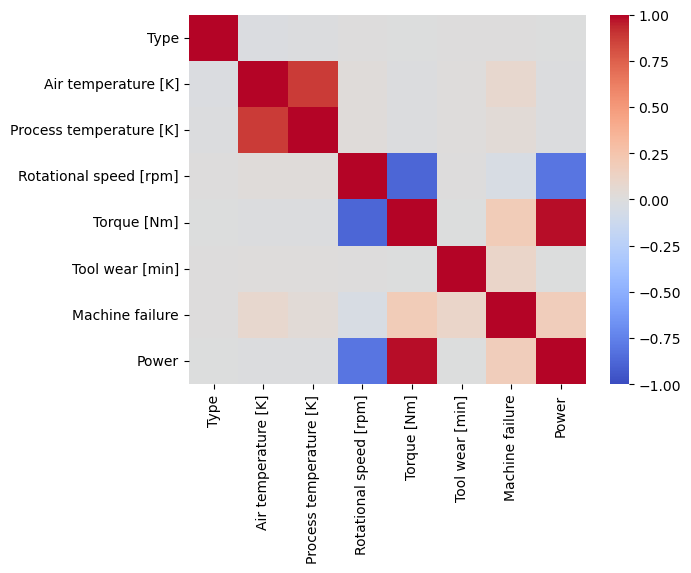

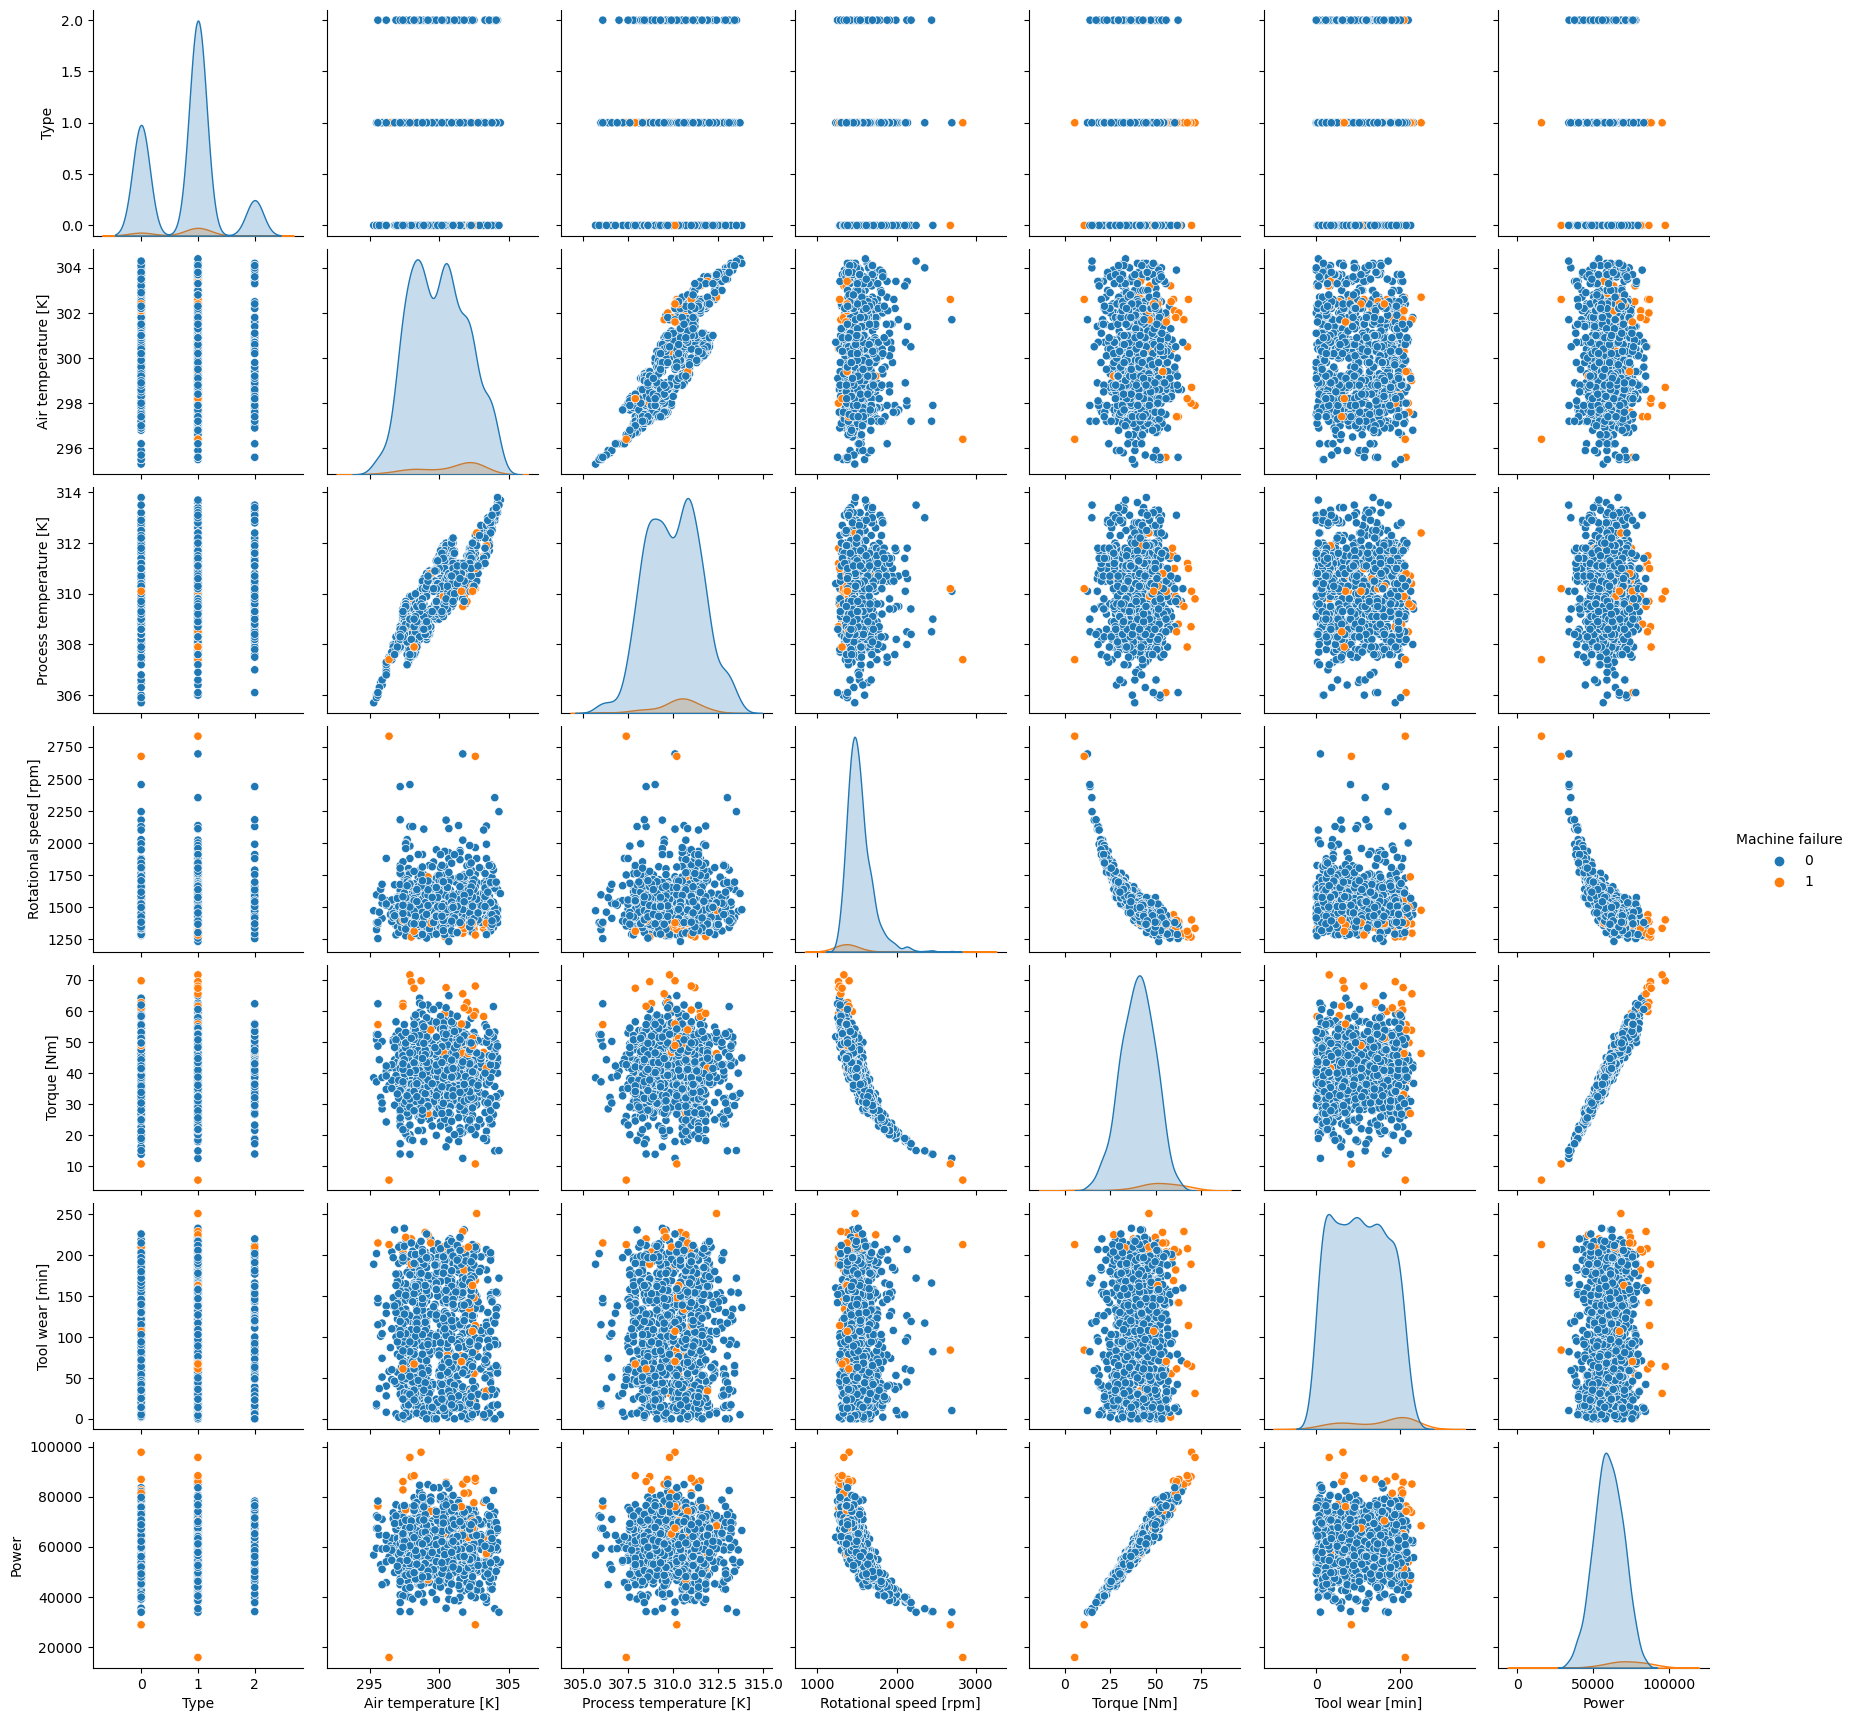

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

""" 1. Type TODO """
data_csv = data_csv[data_csv['Type'] != 'H']
# data_csv.drop(columns = ['Type'], inplace = True)

""" 2. PCA """
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# selected_col = [
#     'Air temperature [K]', 'Process temperature [K]',
#     'Rotational speed [rpm]', 'Torque [Nm]'
# ]
# data_to_pca = data_csv[selected_col]
# scaler = StandardScaler()
# scaled_data = scaler.fit_transform(data_to_pca)
# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(scaled_data)
# explained_variance_ratio = pca.explained_variance_ratio_
# data_csv['PCA_1'] = pca_result[:, 0]
# data_csv['PCA_2'] = pca_result[:, 1]
# data_csv.drop(columns = selected_col, inplace = True)
# label_col = data_csv.pop('Machine failure')
# data_csv['Machine failure'] = label_col

""" 3. Power TODO """
data_csv['Power'] = data_csv[['Rotational speed [rpm]', 'Torque [Nm]']].product(axis = 1)

""" 4. TODO """


""" Result """
fN = 7 # features number
sns.heatmap(data_csv.corr(), vmin = -1, vmax = 1, cmap = 'coolwarm')
sns.pairplot(data_csv.sample(frac = 0.1), hue = 'Machine failure')
plt.show()

将特征与标签分开。

In [19]:
labels_np = data_csv['Machine failure'].to_numpy()

data_csv.drop(columns = ['Machine failure'], inplace = True)
features_np = data_csv.to_numpy()

data_np = np.c_[features_np, labels_np]

print(features_np.shape, labels_np.shape)

(10000, 7) (10000,)


调用`simple_ml`将其封装为`Dataset`类型，并划分为训练集和测试集。

同时，为了防止随机划分不平衡，我们编写一个新的函数对正负样本分别进行划分，然后合并。

In [20]:
from simple_ml.data.dataset import *
from simple_ml.data.samples import *

dataset = Dataset(data = data_np, preprocess_func = label_split_for_single_output_dataset)
train_dataset_raw, test_dataset = split_train_and_test_dataset_with_equal_binary_label(dataset, 0.3, seed = 42)

print(np.sum(test_dataset.datas[1]) / (np.sum(train_dataset_raw.datas[1]) + np.sum(test_dataset.datas[1])))

0.3008849557522124


接下来，注意到数据集中的正负样本不平衡，出故障的样本数量极少，我们使用多种方法进行处理，例如随机过采样、随机欠采样、聚类欠采样等。

具体地，实现在`simple_ml.data.dataset`中。下面是调用实现，以及经过测试，选择了整体表现略好的随机过采样和聚类欠采样的结合方法。

In [21]:
from imblearn.over_sampling import SVMSMOTE

sampler = SVMSMOTE(random_state = 42)
features_bal, labels_bal = sampler.fit_resample(train_dataset_raw.datas[0], train_dataset_raw.datas[1])
train_dataset_bal = Dataset(data = np.c_[features_bal, labels_bal], preprocess_func = label_split_for_single_output_dataset)

# train_dataset_ru = balance_binary_labels_random_repeat(train_dataset_raw, label_pos = 1, label_neg = 0)
# train_dataset_rd = balance_binary_labels_random_remove(train_dataset_raw, label_pos = 1, label_neg = 0)
# train_dataset_cd = balance_binary_labels_cluster_downsample(train_dataset_raw, label_pos = 1, label_neg = 0)
# train_dataset_comb = balance_binary_labels_combined(train_dataset_raw, label_pos = 1, label_neg = 0, oversample_factor = 10)
# train_dataset_smote = balance_binary_labels_smote(train_dataset_raw, label_pos = 1, label_neg = 0, k_neighbors = 10)

# train_dataset_bal = train_dataset_raw

print(f'Positive samples: {int(np.sum(train_dataset_bal.datas[1]))} / {len(train_dataset_bal.datas[1])}')

Positive samples: 6762 / 13524


最后对训练集的特征进行 Mean Normalization，以便后续训练，并记录参数，同时应用到测试集上。

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()
train_dataset_bal.datas[0] = scaler.fit_transform(train_dataset_bal.datas[0])
test_dataset.datas[0] = scaler.transform(test_dataset.datas[0])

# features_means = np.mean(train_dataset.datas[0], axis = 0)
# features_stds = np.std(train_dataset.datas[0], axis = 0)

# def normalize_with_stored_params(features):
#     return (features - features_means) / features_stds

# train_dataset.datas[0] = normalize_with_stored_params(train_dataset.datas[0])
# test_dataset.datas[0] = normalize_with_stored_params(test_dataset.datas[0])

### Model Training and Testing

先导入 `simple_ml` 中的组件和一些需要的package。

In [23]:
from simple_ml.model import *
from simple_ml.model.layers import *
from simple_ml.training.loss import *
from simple_ml.training.optimizer import *
from simple_ml.evaluation.criterion import *

#### Linear Regression

第一种是直接使用线性回归模型进行拟合。不过由于是二分类问题，因此我们需要给输出加上一个阈值，高于阈值的预测值为1，低于阈值的预测值为0。

线性回归模型的搭建直接使用我们的 `simple_ml` 中的一个 `Linear` 层即可，损失函数我们选取 `MSELoss`。

Epoch: 300 / 3000
Epoch: 600 / 3000
Epoch: 900 / 3000
Epoch: 1200 / 3000
Epoch: 1500 / 3000
Epoch: 1800 / 3000
Epoch: 2100 / 3000
Epoch: 2400 / 3000
Epoch: 2700 / 3000
Epoch: 3000 / 3000


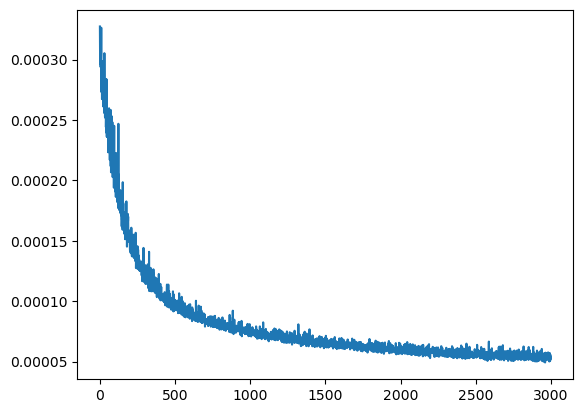

TP: 69, FP: 393, TN: 2506, FN: 33
Test: ACC = 0.8580473175608131, REC = 0.6764705882352942, PRE = 0.14935064935064934, F1 = 0.24468085106382978


In [24]:
def linreg(optimizer, epoch_num, batch_size):
    model = Linear(fN, 1)
    loss_func = MSELoss()
    optimizer.params = model.params

    train_iter = DataIterator(train_dataset_bal, batch_size = batch_size, shuffle = True, cyclic = False)

    train_loss_buffer = []

    for epoch in range(epoch_num):
        train_loss = 0

        for batch, [features, labels] in enumerate(train_iter):
            prediction = model(Variable(features))
            loss = loss_func(prediction, labels)

            model.backward()
            optimizer.step()

            train_loss += loss
        
        train_loss /= len(train_dataset_bal)
        train_loss_buffer.append(train_loss)

        if (epoch + 1) % (epoch_num // 10) == 0:
            print(f'Epoch: {epoch + 1} / {epoch_num}')

    fig = plt.figure(1)
    plt.plot(np.arange(len(train_loss_buffer)), train_loss_buffer)
    plt.show()

    test_prediction = model(Variable(test_dataset.datas[0]))

    decision_threshold = 0.5
    [[TP, FN], [FP, TN]] = eval_binary_confusion_matrix(test_prediction, test_dataset.datas[1], decision_boundary = decision_threshold, label_pos = 1, label_neg = 0)
    print(f'TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}')
    test_accuracy = (TP + TN) / (TP + TN + FP + FN)
    test_recall = TP / (TP + FN)
    test_precision = TP / (TP + FP)
    test_f1_score = 2 * test_precision * test_recall / (test_precision + test_recall) if test_precision + test_recall > 0 else 0
    print(f'Test: ACC = {test_accuracy}, REC = {test_recall}, PRE = {test_precision}, F1 = {test_f1_score}')


optimizer = GD(None, lr = 0.0002)
linreg(optimizer, epoch_num = 3000, batch_size = len(train_dataset_bal) // 10)

#### Perceptron

第二种是使用 Perceptron 模型进行拟合，其前半部分与线性回归模型相同，使用的 Loss 函数则特殊一些，我们实现为 `BinaryPerceptronLoss`。

Epoch: 100 / 1000
Epoch: 200 / 1000
Epoch: 300 / 1000
Epoch: 400 / 1000
Epoch: 500 / 1000
Epoch: 600 / 1000
Epoch: 700 / 1000
Epoch: 800 / 1000
Epoch: 900 / 1000
Epoch: 1000 / 1000


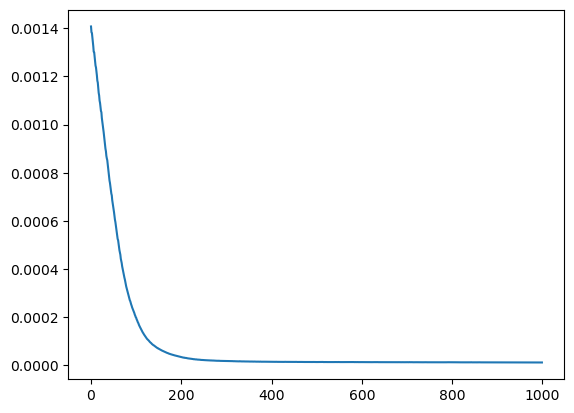

TP: 76, FP: 279, TN: 2620, FN: 26
Test: ACC = 0.8983672109296901, REC = 0.7450980392156863, PRE = 0.2140845070422535, F1 = 0.33260393873085337


In [25]:
def perceptron(optimizer, epoch_num, batch_size):
    model = Linear(fN, 1)
    loss_func = BinaryPerceptronLoss()
    optimizer.params = model.params

    train_iter = DataIterator(train_dataset_bal, batch_size = batch_size, shuffle = True, cyclic = False)

    train_loss_buffer = []

    for epoch in range(epoch_num):
        train_loss = 0

        for batch, [features, labels] in enumerate(train_iter):
            prediction = model(Variable(features))
            loss = loss_func(prediction, labels)

            model.backward()
            optimizer.step()

            train_loss += loss
        
        train_loss /= len(train_dataset_bal)
        train_loss_buffer.append(train_loss)

        if (epoch + 1) % (epoch_num // 10) == 0:
            print(f'Epoch: {epoch + 1} / {epoch_num}')

    fig = plt.figure(1)
    plt.plot(np.arange(len(train_loss_buffer)), train_loss_buffer)
    plt.show()

    test_prediction = model(Variable(test_dataset.datas[0]))
    [[TP, FN], [FP, TN]] = eval_binary_confusion_matrix(test_prediction, test_dataset.datas[1], decision_boundary = 0, label_pos = 1, label_neg = 0)
    print(f'TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}') # TODO
    test_accuracy = (TP + TN) / (TP + TN + FP + FN)
    test_recall = TP / (TP + FN)
    test_precision = TP / (TP + FP)
    test_f1_score = 2 * test_precision * test_recall / (test_precision + test_recall) if test_precision + test_recall > 0 else 0
    print(f'Test: ACC = {test_accuracy}, REC = {test_recall}, PRE = {test_precision}, F1 = {test_f1_score}')


optimizer = GD(None, lr = 0.02)
perceptron(optimizer, epoch_num = 1000, batch_size = len(train_dataset_bal) // 100)

#### Logistic Regression

第三种是使用 Logistic Regression 模型进行拟合，其前半部分与线性回归模型相同，之后使用 `Sigmoid` 激活函数，Loss 函数我们选取 `CrossEntropyLoss`。

Epoch: 200 / 2000
Epoch: 400 / 2000
Epoch: 600 / 2000
Epoch: 800 / 2000
Epoch: 1000 / 2000
Epoch: 1200 / 2000
Epoch: 1400 / 2000
Epoch: 1600 / 2000
Epoch: 1800 / 2000
Epoch: 2000 / 2000


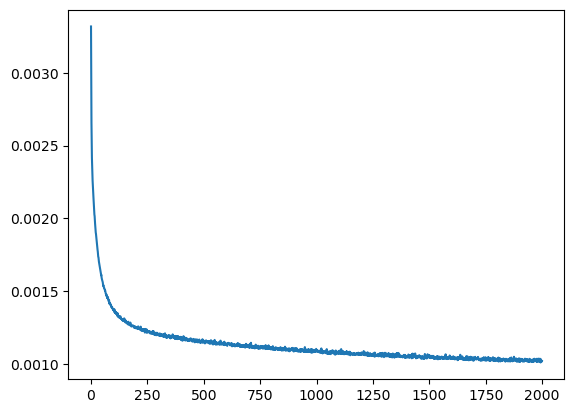

TP: 73, FP: 296, TN: 2603, FN: 29
Test: ACC = 0.8917027657447517, REC = 0.7156862745098039, PRE = 0.1978319783197832, F1 = 0.3099787685774947


In [26]:
def logreg(optimizer, epoch_num, batch_size):
    model = Sequential([
        Linear(fN, 1),
        Sigmoid()
    ])
    loss_func = CrossEntropyLoss()
    optimizer.params = model.params

    train_iter = DataIterator(train_dataset_bal, batch_size = batch_size, shuffle = True, cyclic = False)

    train_loss_buffer = []

    for epoch in range(epoch_num):
        train_loss = 0

        for batch, [features, labels] in enumerate(train_iter):
            prediction = model(Variable(features))
            loss = loss_func(prediction, labels)

            model.backward()
            optimizer.step()

            train_loss += loss
        
        train_loss /= len(train_dataset_bal)
        train_loss_buffer.append(train_loss)

        if (epoch + 1) % (epoch_num // 10) == 0:
            print(f'Epoch: {epoch + 1} / {epoch_num}')

    fig = plt.figure(1)
    plt.plot(np.arange(len(train_loss_buffer)), train_loss_buffer)
    plt.show()

    test_prediction = model(Variable(test_dataset.datas[0]))
    [[TP, FN], [FP, TN]] = eval_binary_confusion_matrix(test_prediction, test_dataset.datas[1], decision_boundary = 0.5, label_pos = 1, label_neg = 0)
    print(f'TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}')
    test_accuracy = (TP + TN) / (TP + TN + FP + FN)
    test_recall = TP / (TP + FN)
    test_precision = TP / (TP + FP)
    test_f1_score = 2 * test_precision * test_recall / (test_precision + test_recall) if test_precision + test_recall > 0 else 0
    print(f'Test: ACC = {test_accuracy}, REC = {test_recall}, PRE = {test_precision}, F1 = {test_f1_score}')


optimizer = GD(None, lr = 0.01)
logreg(optimizer, epoch_num = 2000, batch_size = len(train_dataset_bal) // 50)

#### MLP

第四种是使用MLP。

Epoch: 200 / 2000
Epoch: 400 / 2000
Epoch: 600 / 2000
Epoch: 800 / 2000
Epoch: 1000 / 2000
Epoch: 1200 / 2000
Epoch: 1400 / 2000
Epoch: 1600 / 2000
Epoch: 1800 / 2000
Epoch: 2000 / 2000


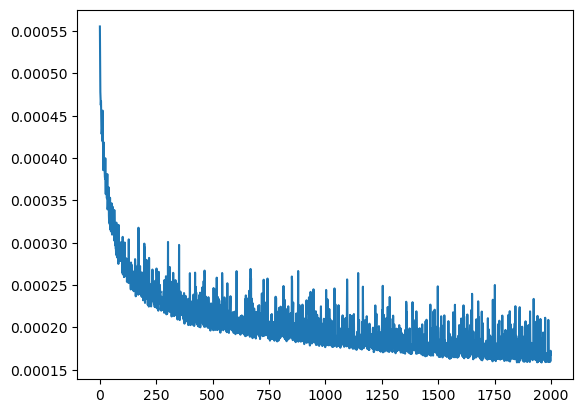

TP: 82, FP: 228, TN: 2671, FN: 20
Test: ACC = 0.9173608797067644, REC = 0.803921568627451, PRE = 0.2645161290322581, F1 = 0.3980582524271845


In [27]:
def mlp(model, loss_func, optimizer, epoch_num, batch_size):
    train_iter = DataIterator(train_dataset_bal, batch_size = batch_size, shuffle = True, cyclic = False)

    train_loss_buffer = []

    for epoch in range(epoch_num):
        train_loss = 0

        for batch, [features, labels] in enumerate(train_iter):
            prediction = model(Variable(features))
            loss = loss_func(prediction, labels)

            model.backward()
            optimizer.step()

            train_loss += loss
        
        train_loss /= len(train_dataset_bal)
        train_loss_buffer.append(train_loss)

        if (epoch + 1) % (epoch_num // 10) == 0:
            print(f'Epoch: {epoch + 1} / {epoch_num}')

    fig = plt.figure(1)
    plt.plot(np.arange(len(train_loss_buffer)), train_loss_buffer)
    plt.show()

    test_prediction = model(Variable(test_dataset.datas[0]))
    [[TP, FN], [FP, TN]] = eval_binary_confusion_matrix(test_prediction, test_dataset.datas[1], decision_boundary = 0.5, label_pos = 1, label_neg = 0)
    print(f'TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}')
    test_accuracy = (TP + TN) / (TP + TN + FP + FN)
    test_recall = TP / (TP + FN)
    test_precision = TP / (TP + FP)
    test_f1_score = 2 * test_precision * test_recall / (test_precision + test_recall) if test_precision + test_recall > 0 else 0
    print(f'Test: ACC = {test_accuracy}, REC = {test_recall}, PRE = {test_precision}, F1 = {test_f1_score}')


model = Sequential([
    Linear(fN, 100),
    ReLU(),
    Linear(100, 1),
    Sigmoid()
])
loss_func = CrossEntropyLoss()
optimizer = GD(model.params, lr = 0.01)
mlp(model, loss_func, optimizer, epoch_num = 2000, batch_size = len(train_dataset_bal) // 10)

### Comparison

前面分别实现了 Linear Regression，Perceptron，Logistic Regression 和 MLP，并进行了简单的测试（细致的调整在接下来进行）。

简单测试中反映出的情况是，线性回归、感知器模型以及逻辑回归所得到的 Test F1 Score 相差不大，都在 0.3 略少一些的程度。其中线性回归结果稳定但整体效果稍低于其他模型；感知器模型的损失函数由于非凸，训练结果有时效果不佳，多次尝试后较好的结果和其他相差不多。

MLP 只进行了简单的测试，单隐藏层（100 个神经元），效果较明显优于其他模型，且可以观察到还有提升的空间，后续进行超参数调整。

总体来看，由于数据标签不均衡，所以 Accuracy 没有参考价值。F1 由 Recall 和 Precision 计算得来，其中都是 Recall 偏高而 Precision 偏低，也就是经常将 0 错判为 1。

此外，以上结果也依赖之前对**训练集数据**进行的一系列变换、归一化、上采样等操作：

1. 根据原数据相关性热图，使用 PCA 对相关性较高的两组特征进行合并，不过效果不好，注释了；

2. 在添加了一项 Power = Rotational speed * Torque 特征之后，模型训练后的 Test F1 Score 整体略有提升，来到了 0.3 以上，以感知器模型提升最为明显。参考这一点，我们再加入其他特征项进行尝试；



### Hyperparameter Tuning